# Análisis de Perfil i Desempeño Professional

**Desafío 1**  
Quin és el perfil sociodemogràfic dels empleats que tenim a l'empresa, i com podem utilitzar aquesta informació per dissenyar polítiques de talent més adaptades a les seves necessitats i potenciar el seu compromís i desenvolupament professional?

*Punts a respondre (dibuix de la pregunta)* 
- Perfil sociodemogràfic (Columnes: 'ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 'Education', 'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height','BMI_calculated')
- Com podem utilitzar aquesta informació per dissenyar polítiques de talent més adaptades a les seves necessitats i potenciar el seu compromís i desenvolupament professional (valorar les altres variables no demogràfiques (e.g. 'Absenteeism_hours', hit target) o simplement fer-ho de forma teòrica?)

## Librerías

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

## Documentos

In [2]:
DATA_INPUT_FILE = '../../Data/clean/clean_data_25052026.csv'

In [3]:
df = pd.read_csv(DATA_INPUT_FILE)

In [5]:
df.sample(5)

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours
659,36,28.0,Consulta dental,12.0,Diciembre,3,Martes,2,Primavera,118,...,Secundaria,1,1,0,0,98,178,31,30.9,1
533,22,23.0,Consulta médica,9.0,Septiembre,2,Lunes,1,Invierno,179,...,Posgrado,0,0,0,0,56,171,19,19.2,2
16,10,13.0,Sistema musculoesquelético,8.0,Agosto,2,Lunes,1,Invierno,361,...,Secundaria,1,1,0,4,80,172,27,27.0,40
414,22,13.0,Sistema musculoesquelético,1.0,Enero,2,Lunes,3,Verano,179,...,Posgrado,0,0,0,0,56,171,19,19.2,3
385,3,27.0,Fisioterapia,2.0,Febrero,2,Lunes,3,Verano,179,...,Secundaria,0,1,0,0,89,170,31,30.8,3


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       740 non-null    int64  
 1   Reason_absence           697 non-null    float64
 2   Reason_absence_name      697 non-null    str    
 3   Month_absence            737 non-null    float64
 4   Month_absence_name       737 non-null    str    
 5   Day_week                 740 non-null    int64  
 6   Day_week_name            740 non-null    str    
 7   Seasons                  740 non-null    int64  
 8   Seasons_name             740 non-null    str    
 9   Transportation_expense   740 non-null    int64  
 10  Distance_Residence_Work  740 non-null    int64  
 11  Service_time             740 non-null    int64  
 12  Age                      740 non-null    int64  
 13  Work_load_Average_day    740 non-null    float64
 14  Hit_target               740 non-null

In [8]:
df.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours'],
      dtype='str')

## Viz

### Perfil sociodemogràfic

In [9]:
perfil_col = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time', 'Age', 'Education', 'Education_name', 'Son', 'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height','BMI_calculated']

In [10]:
df_perfil = df.loc[:, perfil_col]
df_perfil.sample(5)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated
552,3,179,51,18,38,1,Secundaria,0,1,0,0,89,170,30.8
116,28,225,26,9,28,1,Secundaria,1,0,0,2,69,169,24.2
437,3,179,51,18,38,1,Secundaria,0,1,0,0,89,170,30.8
684,9,228,14,16,58,1,Secundaria,2,0,0,1,65,172,22.0
358,28,225,26,9,28,1,Secundaria,1,0,0,2,69,169,24.2


In [11]:
df_perfil.info()

<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       740 non-null    int64  
 1   Transportation_expense   740 non-null    int64  
 2   Distance_Residence_Work  740 non-null    int64  
 3   Service_time             740 non-null    int64  
 4   Age                      740 non-null    int64  
 5   Education                740 non-null    int64  
 6   Education_name           740 non-null    str    
 7   Son                      740 non-null    int64  
 8   Social_drinker           740 non-null    int64  
 9   Social_smoker            740 non-null    int64  
 10  Pet                      740 non-null    int64  
 11  Weight                   740 non-null    int64  
 12  Height                   740 non-null    int64  
 13  BMI_calculated           740 non-null    float64
dtypes: float64(1), int64(12), str(1)
memo

In [12]:
df_perfil.duplicated().sum()

np.int64(704)

In [13]:
df_perfil.drop_duplicates(inplace=True)

In [14]:
df_perfil.shape

(36, 14)

In [18]:
df_perfil.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36.0,18.500000,10.535654,1.0,9.75,18.5,27.250,36.0
Transportation_expense,36.0,237.277778,73.982087,118.0,179.00,235.0,289.000,388.0
Distance_Residence_Work,36.0,27.194444,14.520566,5.0,15.00,25.5,37.500,52.0
Service_time,36.0,12.388889,5.309171,1.0,9.00,13.0,14.000,29.0
Age,36.0,38.333333,7.917431,27.0,32.00,37.5,43.000,58.0
Education,36.0,1.361111,0.761682,1.0,1.00,1.0,1.000,4.0
Son,36.0,1.138889,1.018480,0.0,0.00,1.0,2.000,4.0
Social_drinker,36.0,0.527778,0.506309,0.0,0.00,1.0,1.000,1.0
Social_smoker,36.0,0.194444,0.401386,0.0,0.00,0.0,0.000,1.0
Pet,36.0,1.277778,2.092314,0.0,0.00,0.0,2.000,8.0


In [19]:
for col in perfil_col:
    print(col)
    print(df[col].nunique())
    print(df[col].unique())
    print('-----')

ID
36
[14 36  9 28 11 13 34 22 26 20 10 15 17 24  3 18  7  1 30  5  6  2 31 27
 33 23 21 25 12 32 16 29 19  8  4 35]
-----
Transportation_expense
24
[155 118 228 225 289 369 179 300 260 361 291 246 330 279 235 157 189 388
 184 248 378 268 233 231]
-----
Distance_Residence_Work
25
[12 13 14 26 36 17 10 50 52 31 22 25 51 16  5 11 27 20 29 15 42 49 48 35
 45]
-----
Service_time
18
[14 18 16  9 13 12 10 11  3 17  4  6  7  8  1 29 24 15]
-----
Age
22
[34 50 58 28 33 31 37 30 43 36 40 41 38 39 29 48 27 47 32 49 46 53]
-----
Education
4
[1 3 2 4]
-----
Education_name
4
<StringArray>
['Secundaria', 'Posgrado', 'Grado', 'Máster/Doctorado']
Length: 4, dtype: str
-----
Son
5
[2 1 3 0 4]
-----
Social_drinker
2
[1 0]
-----
Social_smoker
2
[0 1]
-----
Pet
6
[0 1 2 4 5 8]
-----
Weight
26
[ 95  98  65  69  90  70  83  56  77  80  73  63  67  89  84  68  88  75
 106  76  58  86  79 108  94 100]
-----
Height
14
[196 178 172 169 171 175 168 170 182 185 167 163 165 174]
-----
BMI_calculated
32
[24.7 30.9 

ID


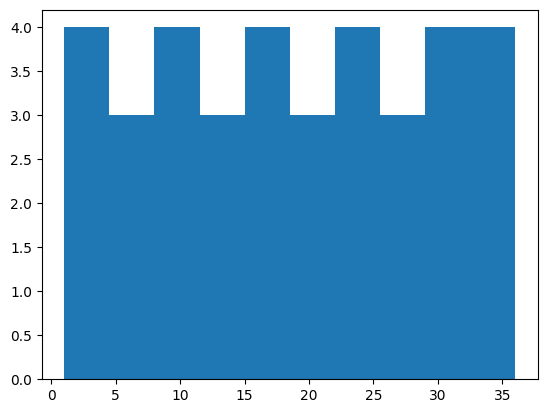

-----
Transportation_expense


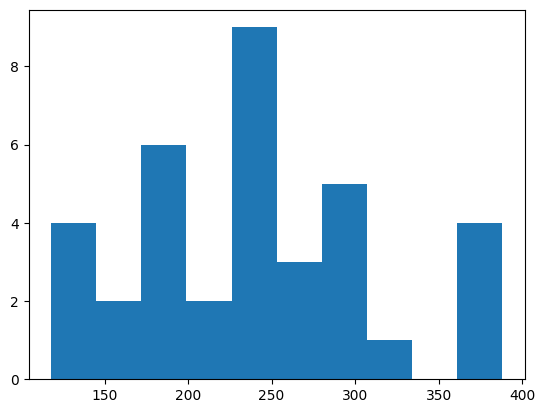

-----
Distance_Residence_Work


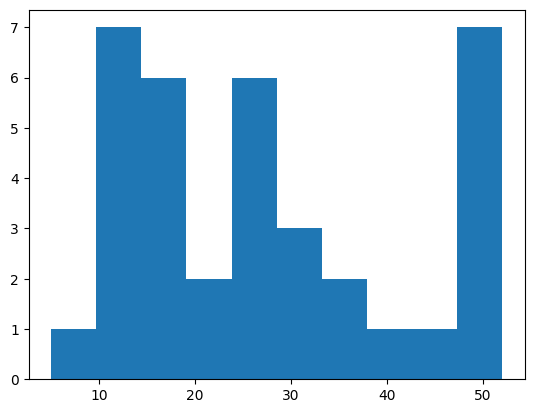

-----
Service_time


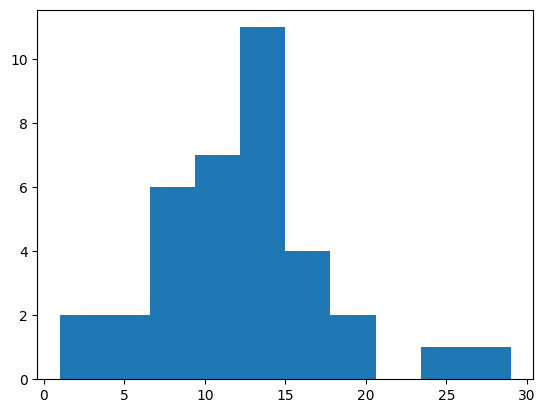

-----
Age


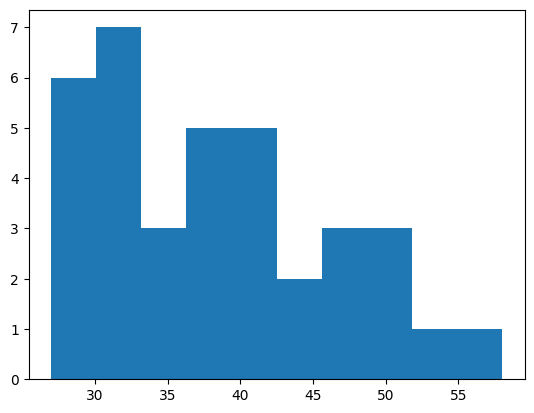

-----
Education


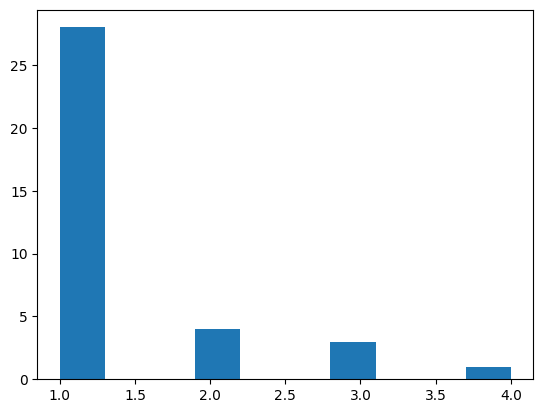

-----
Education_name


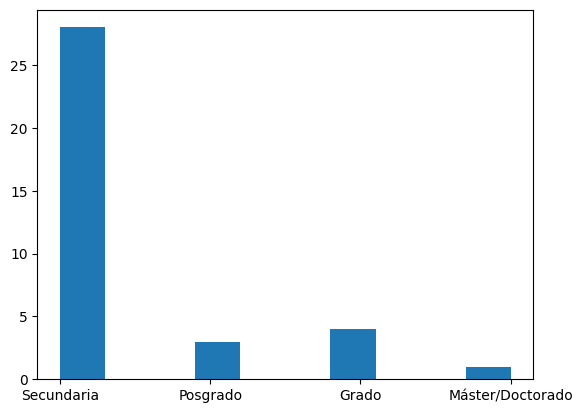

-----
Son


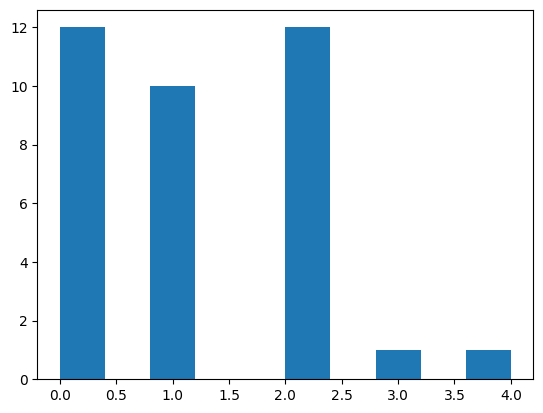

-----
Social_drinker


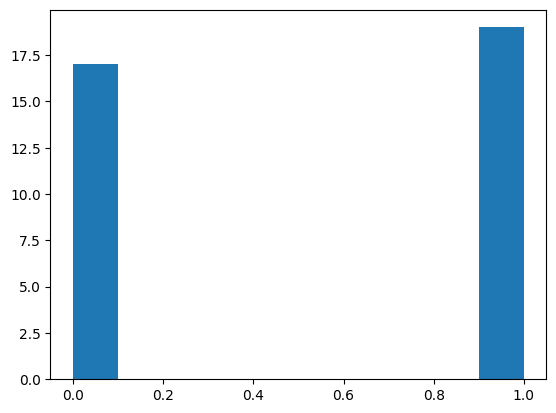

-----
Social_smoker


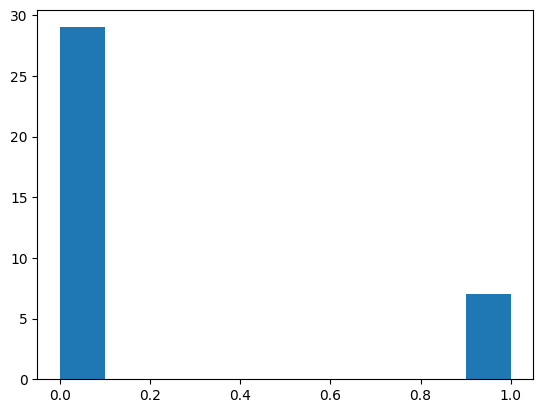

-----
Pet


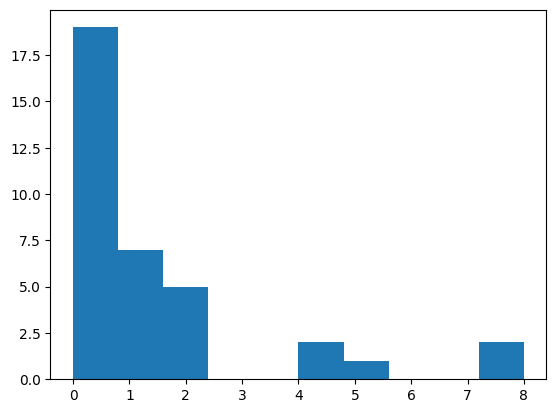

-----
Weight


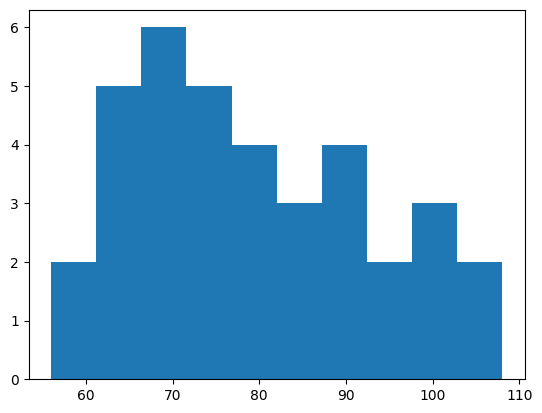

-----
Height


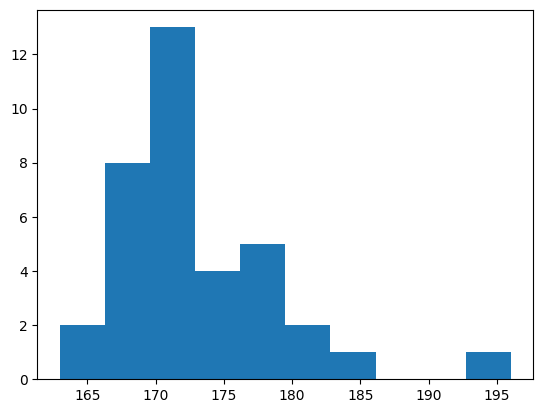

-----
BMI_calculated


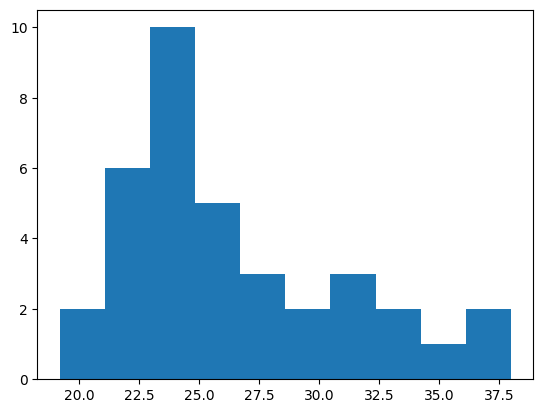

-----


In [16]:
for col in perfil_col:
    print(col)
    plt.hist(df_perfil[col])
    plt.show()
    print('-----')